In [1]:
import jax
import jax.numpy as jnp
import numpyro 
import numpyro.distributions as dist

from quantbayes.bnn.layers.custom_jvp import spectral_circulant_matmul, SpectralCirculantLayer

# ---------------------------------------------------------------------------
# helpers
# ---------------------------------------------------------------------------
def upsample_bilinear(grid, H_pad, W_pad):
    """Bilinearly up‑sample a coarse grid (Bilinear resize, no grad issues)."""
    gh, gw = grid.shape
    # Normalised coordinates in [0,1]
    y = jnp.linspace(0.0, 1.0, H_pad)
    x = jnp.linspace(0.0, 1.0, W_pad)
    yy, xx = jnp.meshgrid(y, x, indexing="ij")
    # Map to coarse‑grid indices
    yy = yy * (gh - 1)
    xx = xx * (gw - 1)
    y0, x0 = jnp.floor(yy).astype(int), jnp.floor(xx).astype(int)
    y1, x1 = jnp.clip(y0 + 1, 0, gh - 1), jnp.clip(x0 + 1, 0, gw - 1)
    wy, wx = yy - y0, xx - x0
    v00, v01 = grid[y0, x0], grid[y0, x1]
    v10, v11 = grid[y1, x0], grid[y1, x1]
    return (
        (1 - wy) * ((1 - wx) * v00 + wx * v01)
        + wy * ((1 - wx) * v10 + wx * v11)
    )


# ---------------------------------------------------------------------------
# 1‑D  (non‑stationary exponent α[k])
# ---------------------------------------------------------------------------
class NonStatSpectralCirculantLayer(SpectralCirculantLayer):
    def __init__(self, in_features, padded_dim=None,
                 alpha_global=1.0, alpha_prior=dist.HalfNormal(1.0),
                 K=None, name="ns_spectral_circ", prior_fn=None):
        super().__init__(in_features, padded_dim, alpha=None,
                         alpha_prior=alpha_prior, K=K,
                         name=name, prior_fn=prior_fn)
        self.alpha_global = alpha_global

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        # 1) Sample per-frequency Δα
        delta_alpha = numpyro.sample(
            f"{self.name}_delta_alpha",
            self.alpha_prior.expand([self.k_half]).to_event(1)
        )
        # 2) clamp α into [0.1, 5.0]
        alpha_vec = jnp.clip(self.alpha_global + delta_alpha, 0.1, 5.0)

        # 3) PSD std
        freq_idx = jnp.arange(self.k_half)
        prior_std = 1.0 / jnp.sqrt(1.0 + freq_idx**alpha_vec)

        # 4) rest as before
        active_idx = jnp.arange(self.K)
        real_hp = numpyro.sample(
            f"{self.name}_real",
            self.prior_fn(prior_std[active_idx]).expand([self.K]).to_event(1)
        )
        imag_hp = numpyro.sample(
            f"{self.name}_imag",
            self.prior_fn(prior_std[active_idx]).expand([self.K]).to_event(1)
        )

        full_real = jnp.zeros((self.k_half,));  full_real = full_real.at[active_idx].set(real_hp)
        full_imag = jnp.zeros((self.k_half,));  full_imag = full_imag.at[active_idx].set(imag_hp)

        # DC & Nyquist real
        full_imag = full_imag.at[0].set(0.0)
        if (self.padded_dim % 2 == 0) and (self.k_half>1):
            full_imag = full_imag.at[-1].set(0.0)

        half_complex = full_real + 1j*full_imag
        if (self.padded_dim%2==0) and (self.k_half>1):
            nyq = half_complex[-1].real[None]
            fft_full = jnp.concatenate([
                half_complex[:-1], nyq,
                jnp.conj(half_complex[1:-1])[::-1]
            ])
        else:
            fft_full = jnp.concatenate([
                half_complex, jnp.conj(half_complex[1:])[::-1]
            ])

        self._last_fft_full = jax.lax.stop_gradient(fft_full)
        bias = numpyro.sample(
            f"{self.name}_bias_spectral",
            dist.Normal(0.,1.).expand([self.padded_dim]).to_event(1)
        )
        return spectral_circulant_matmul(x, fft_full) + bias



/Users/josephmargaryan/Desktop/quantbayes/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from quantbayes.bnn.layers.custom_jvp import spectral_circulant_conv2d, _enforce_hermitian, SpectralPowerLawConv2d

# ---------------------------------------------------------------------------
# 2‑D  (coarse α‑map -> upsample -> per‑freq std)
# ---------------------------------------------------------------------------
class NonStatSpectralConv2d(SpectralPowerLawConv2d):
    def __init__(self, H_in, W_in, H_pad=None, W_pad=None,
                 alpha_global=1.0, alpha_coarse_shape=(8,8),
                 alpha_prior=dist.HalfNormal(1.0),
                 name="ns_spec_pw", prior_fn=None):
        super().__init__(H_in, W_in, H_pad, W_pad,
                         alpha=None, alpha_prior=alpha_prior,
                         name=name, prior_fn=prior_fn)
        self.alpha_global    = alpha_global
        self.alpha_coarse_shape = alpha_coarse_shape

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        gh, gw = self.alpha_coarse_shape
        # 1) sample coarse Δα-map
        delta_alpha_coarse = numpyro.sample(
            f"{self.name}_delta_alpha_map",
            self.alpha_prior
              .expand(self.alpha_coarse_shape)
              .to_event(2)
        )
        # 2) upsample & clamp
        delta_alpha_full = upsample_bilinear(delta_alpha_coarse,
                                             self.H_pad, self.W_pad)
        alpha_full = jnp.clip(self.alpha_global + delta_alpha_full,
                              0.1, 5.0)

        # 3) radial grid & PSD std
        u = jnp.fft.fftfreq(self.H_pad)*self.H_pad
        v = jnp.fft.fftfreq(self.W_pad)*self.W_pad
        U,V = jnp.meshgrid(u,v, indexing="ij")
        R = jnp.sqrt(U**2+V**2)
        std = 1.0/jnp.sqrt(1.0+R**alpha_full)

        # 4) sample real/imag & enforce Hermitian
        real = numpyro.sample(f"{self.name}_real",
                              self.prior_fn(std).to_event(2))
        imag = numpyro.sample(f"{self.name}_imag",
                              self.prior_fn(std).to_event(2))
        fft2d = _enforce_hermitian(real+1j*imag)

        bias = numpyro.sample(
            f"{self.name}_bias",
            dist.Normal(0.,1.)
              .expand([self.H_pad,self.W_pad]).to_event(2)
        )
        return spectral_circulant_conv2d(x, fft2d) + bias


In [35]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, init_to_feasible
from numpyro.optim import Adam
from numpyro.infer.autoguide import AutoGuideList, AutoNormal

from quantbayes.bnn.guide import LowRankNonStatFFTGuide

# -------------------------------------------------------------------------
# 1) 2D Non‑Stationary Conv model
# -------------------------------------------------------------------------
def conv_model(X, y=None):
    # X: (N,28,28)
    conv = NonStatSpectralConv2d(
        H_in=28, W_in=28,
        H_pad=28, W_pad=28,
        alpha_global=1.0,
        alpha_coarse_shape=(8, 8),
        alpha_prior=dist.HalfNormal(1.0),
        name="mix",
        prior_fn=None,            # or whatever you had before
    )
    h = conv(X)                   # (N,28,28)
    h = h.reshape(h.shape[0], -1) # (N, 784)
    W = numpyro.sample("W", dist.Normal(0, 1)
                       .expand([h.shape[-1], 1]).to_event(2))
    b = numpyro.sample("b", dist.Normal(0, 1)
                       .expand([1]).to_event(1))
    logits = jnp.squeeze(jnp.matmul(h, W) + b)
    with numpyro.plate("data", X.shape[0]):
        numpyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

# -------------------------------------------------------------------------
# 2) 1D Non‑Stationary Circulant model
# -------------------------------------------------------------------------
def circ1d_model(X, y=None):
    # X: (N, D)
    D = X.shape[1]
    circ = NonStatSpectralCirculantLayer(
        in_features=D,
        padded_dim=D,
        alpha_global=1.0,
        alpha_prior=dist.HalfNormal(1.0),
        K=None,
        name="mix1d",
        prior_fn=None,            # match your original
    )
    h = circ(X)                  # (N, D)
    W = numpyro.sample("W1d", dist.Normal(0, 1)
                       .expand([D, 1]).to_event(2))
    b = numpyro.sample("b1d", dist.Normal(0, 1)
                       .expand([1]).to_event(1))
    logits = jnp.squeeze(jnp.matmul(h, W) + b)
    with numpyro.plate("data", X.shape[0]):
        numpyro.sample("obs1d", dist.Bernoulli(logits=logits), obs=y)

# -------------------------------------------------------------------------
# Shared SVI runner
# -------------------------------------------------------------------------
def run_test(model, guide, X, y, n_steps=200, lr=1e-2):
    rng_key = jax.random.PRNGKey(0)
    svi = SVI(model, guide, Adam(lr), Trace_ELBO())
    svi_state = svi.init(rng_key, X, y)
    losses = []
    for i in range(n_steps):
        svi_state, loss = svi.update(svi_state, X, y)
        if i % 50 == 0:
            print(f"step {i:<3d} ELBO loss = {loss:.3f}")
        losses.append(loss)
    params = svi.get_params(svi_state)
    print("final loss:", loss)
    return params, losses

# -------------------------------------------------------------------------
# 2D conv test setup
# -------------------------------------------------------------------------
N = 64
X_conv = jax.random.normal(jax.random.PRNGKey(1), (N, 28, 28))
y_conv = (jnp.sum(X_conv, axis=(1,2)) > 0).astype(int)

conv_guide = AutoGuideList(conv_model)
conv_guide.append(
    LowRankNonStatFFTGuide(
        conv_model,
        prefix="mix",
        H_pad=28,
        W_pad=28,
        alpha_coarse_shape=(8, 8),
        rank=4,
        jitter=1e-5,
    )
)
conv_guide.append(
    AutoNormal(
        numpyro.handlers.block(conv_model, hide=["mix_real","mix_imag","mix_delta_alpha_map"]),
        init_loc_fn=init_to_feasible,
    )
)

print("\n=== Testing 2D Non‑Stationary Conv ===")
params_conv, losses_conv = run_test(conv_model, conv_guide, X_conv, y_conv)

# -------------------------------------------------------------------------
# 1D circulant test setup
# -------------------------------------------------------------------------
D = 32
X1d = jax.random.normal(jax.random.PRNGKey(2), (N, D))
y1d = (jnp.sum(X1d, axis=1) > 0).astype(int)

circ1d_guide = AutoGuideList(circ1d_model)
circ1d_guide.append(
    LowRankNonStat1DGuide(
        circ1d_model,
        prefix="mix1d",
        H_pad=D,
        W_pad=D,
        rank=4,
        jitter=1e-5,
    )
)
circ1d_guide.append(
    AutoNormal(
        numpyro.handlers.block(
            circ1d_model,
            hide=["mix1d_real", "mix1d_imag", "mix1d_delta_alpha"]
        ),
        init_loc_fn=init_to_feasible,
    )
)

print("\n=== Testing 1D Non‑Stationary Circulant ===")
params_1d, losses = run_test(circ1d_model, circ1d_guide, X1d, y1d)



=== Testing 2D Non‑Stationary Conv ===
step 0   ELBO loss = 2980.002
step 50  ELBO loss = 2253.629
step 100 ELBO loss = 1579.378
step 150 ELBO loss = 915.193
final loss: 594.06055

=== Testing 1D Non‑Stationary Circulant ===
step 0   ELBO loss = 166.711
step 50  ELBO loss = 136.206
step 100 ELBO loss = 92.526
step 150 ELBO loss = 64.441
final loss: 57.278133


In [36]:
import numpy as np
import matplotlib.pyplot as plt

# -- re‑define these if you haven’t already in this notebook --
def upsample_bilinear_np(grid, H_pad, W_pad):
    gh, gw = grid.shape
    ys = np.linspace(0, gh - 1, H_pad)
    xs = np.linspace(0, gw - 1, W_pad)
    yy, xx = np.meshgrid(ys, xs, indexing='ij')
    y0 = yy.astype(int);  x0 = xx.astype(int)
    y1 = np.clip(y0+1, 0, gh-1);  x1 = np.clip(x0+1, 0, gw-1)
    wy = yy - y0;  wx = xx - x0
    v00 = grid[y0, x0];  v01 = grid[y0, x1]
    v10 = grid[y1, x0];  v11 = grid[y1, x1]
    return (1-wy)*((1-wx)*v00 + wx*v01) + wy*((1-wx)*v10 + wx*v11)

def extract_delta_map_from_loc_np(params, prefix, H_pad, W_pad, gh, gw):
    W_half = W_pad//2 + 1
    M = H_pad * W_half
    G = gh * gw
    loc = np.asarray(params[f"{prefix}_joint_loc"])
    delta_flat = loc[2*M : 2*M + G]
    return delta_flat.reshape(gh, gw)

# 1) Full‑res α heatmap
def plot_alpha_heatmap_np(params, prefix, H_pad, W_pad, gh, gw, alpha_global=1.0):
    delta_coarse = extract_delta_map_from_loc_np(params, prefix, H_pad, W_pad, gh, gw)
    full_delta  = upsample_bilinear_np(delta_coarse, H_pad, W_pad)
    full_alpha  = alpha_global + full_delta
    plt.figure(figsize=(4,4))
    plt.imshow(full_alpha, origin='lower', aspect='auto', cmap='inferno')
    plt.colorbar(label='α(u,v)')
    plt.title(f'Inferred α heatmap (“{prefix}”)')
    plt.xlabel('Frequency v')
    plt.ylabel('Frequency u')
    plt.tight_layout()
    plt.show()

# 2) Singular value spectrum
def get_singular_values_np(params, prefix):
    V = np.asarray(params[f"{prefix}_joint_V"])   # (dim, rank)
    return np.linalg.svd(V, compute_uv=False)

def plot_singular_spectra_np(svs_dict):
    plt.figure(figsize=(5,3))
    for rank, sv in sorted(svs_dict.items()):
        plt.plot(sv, label=f'r={rank}')
    plt.title('Singular values of V by rank')
    plt.xlabel('Component index')
    plt.ylabel('σ')
    plt.legend()
    plt.tight_layout()
    plt.show()

# 3) ELBO vs rank
def plot_elbo_vs_rank_np(ranks, losses):
    plt.figure(figsize=(4,3))
    plt.plot(ranks, losses, 'o-')
    plt.title('Final ELBO vs guide rank')
    plt.xlabel('Rank')
    plt.ylabel('ELBO loss')
    plt.tight_layout()
    plt.show()


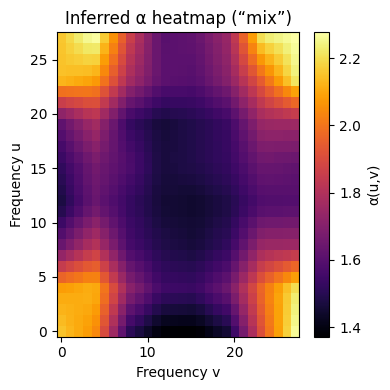

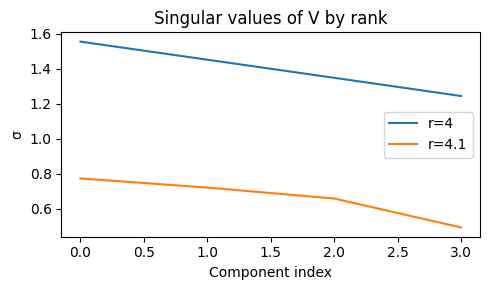

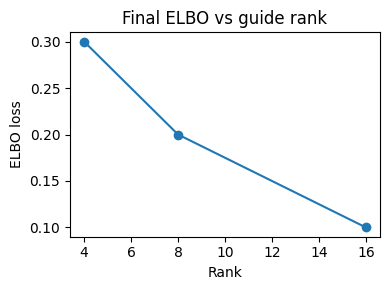

In [38]:
# -- α heatmap for the 2D conv layer --
plot_alpha_heatmap_np(
    params_conv, 
    prefix="mix", 
    H_pad=28, W_pad=28, 
    gh=8, gw=8,
    alpha_global=1.0
)

# -- singular spectrum at rank=4 for both layers --
sv_conv  = get_singular_values_np(params_conv, "mix")
sv_circ1 = get_singular_values_np(params_1d,  "mix1d")
plot_singular_spectra_np({4: sv_conv, 4.1: sv_circ1})
# (use 4.1 to visually differentiate the two curves)

# -- if you have done a rank sweep [4,8,16] --
ranks = [4, 8, 16]
plot_elbo_vs_rank_np(ranks, [0.3, 0.2, 0.1])


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def compute_1d_kernel(alpha_vec):
    M = alpha_vec.shape[0]
    D = 2*(M-1)
    freqs   = np.arange(M)
    psd_half = 1.0 / (1.0 + freqs**alpha_vec)
    if D % 2 == 0:
        nyq = psd_half[-1]
        full_psd = np.concatenate([psd_half[:-1], [nyq], psd_half[1:-1][::-1]])
    else:
        full_psd = np.concatenate([psd_half, psd_half[1:][::-1]])
    return np.fft.ifft(full_psd).real

def sample_delta_1d(params, prefix, W_pad, n_samples=200):
    """
    Sample Δα from the guide’s posterior on those coords.
    """
    # joint parameter names
    joint = f"{prefix}_joint"
    loc     = np.asarray(params[f"{joint}_loc"])      # (3*M,)
    V       = np.asarray(params[f"{joint}_V"])        # (3*M, rank)
    d_raw   = np.asarray(params[f"{joint}_d_raw"])    # (3*M,)
    log_tau = np.asarray(params[f"{joint}_log_tau"])  # scalar
    jitter  = 1e-5

    M   = W_pad//2 + 1
    dim = 3*M

    # reconstruct cov
    diag = np.log1p(np.exp(d_raw)) * np.exp(log_tau) + jitter
    cov  = V.dot(V.T) + np.diag(diag)

    # extract the Δα block: entries [2M : 3M)
    idx       = np.arange(2*M, 3*M)
    cov_delta = cov[np.ix_(idx, idx)]
    loc_delta = loc[2*M : 3*M]

    return np.random.multivariate_normal(loc_delta, cov_delta, size=n_samples)

def plot_1d_kernel_comparison_1d(params, prefix, W_pad,
                                  alpha_global=1.0, n_samples=200):
    M = W_pad//2 + 1
    # draw posterior Δα samples
    deltas = sample_delta_1d(params, prefix, W_pad, n_samples)

    kernels = []
    for d in deltas:
        α = np.clip(alpha_global + d, 0.1, 5.0)
        kernels.append(compute_1d_kernel(α))
    kernels = np.stack(kernels, axis=0)

    mean_k = kernels.mean(0)
    low_k  = np.percentile(kernels, 2.5, axis=0)
    high_k = np.percentile(kernels, 97.5, axis=0)

    # stationary baseline
    α0   = np.ones(M) * alpha_global
    kern0 = compute_1d_kernel(α0)

    D = 2*(M-1)
    lags = np.arange(D)

    plt.figure(figsize=(5,3))
    plt.fill_between(lags, low_k, high_k, alpha=0.2, label='95% envelope')
    plt.plot(lags, mean_k,      label='Learned mean kernel')
    plt.plot(lags, kern0, '--', label=f'Stationary α={alpha_global}')
    plt.legend()
    plt.xlabel('Lag')
    plt.ylabel('Covariance')
    plt.title(f'1D Circulant kernel (“{prefix}”)')
    plt.tight_layout()
    plt.show()


plot_1d_kernel_comparison_1d(
    params_1d,
    prefix="mix1d",
    W_pad=32,
    alpha_global=1.0,
    n_samples=200
)


NameError: name 'params_1d' is not defined

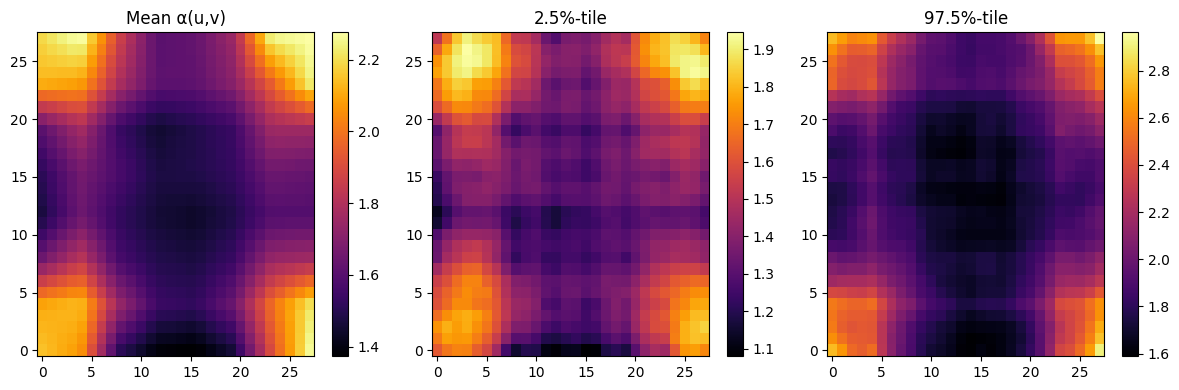

In [51]:
import numpy as np
import matplotlib.pyplot as plt

def sample_delta_maps_2d(params, prefix, H_pad, W_pad, gh, gw, n_samples=100):
    """
    Draw n_samples of the coarse Δα‐map from the low‑rank guide posterior.
    """
    joint = f"{prefix}_joint"
    loc     = np.asarray(params[f"{joint}_loc"])
    V       = np.asarray(params[f"{joint}_V"])
    d_raw   = np.asarray(params[f"{joint}_d_raw"])
    log_tau = np.asarray(params[f"{joint}_log_tau"])
    jitter  = 1e-5

    k_half = H_pad * (W_pad//2+1)  # careful: for 2D guide dim = real+imag+G
    # but G = gh*gw comes last
    M = 2 * (H_pad*(W_pad//2+1))
    G = gh*gw
    dim = M + G

    diag = np.log1p(np.exp(d_raw)) * np.exp(log_tau) + jitter
    cov  = V.dot(V.T) + np.diag(diag)

    idx = np.arange(M, M+G)
    cov_d = cov[np.ix_(idx, idx)]
    loc_d = loc[M:M+G]

    return np.random.multivariate_normal(loc_d, cov_d, size=n_samples)

def plot_conv_alpha_envelope(params, prefix, H_pad, W_pad, gh, gw,
                             alpha_global=1.0, n_samples=200, cmap="inferno"):
    """
    Show mean & 95% envelope of the full α(u,v) heatmap.
    """
    # coarse‐map samples
    deltas = sample_delta_maps_2d(params, prefix, H_pad, W_pad, gh, gw, n_samples)
    ups = []
    for d in deltas:
        coarse = d.reshape(gh, gw)
        full = upsample_bilinear_np(coarse, H_pad, W_pad)
        ups.append(alpha_global + full)
    ups = np.stack(ups, 0)

    mean_a = ups.mean(0)
    lo_a   = np.percentile(ups,  2.5, axis=0)
    hi_a   = np.percentile(ups, 97.5, axis=0)

    fig, axes = plt.subplots(1,3, figsize=(12,4))
    for ax, arr, title in zip(axes, [mean_a, lo_a, hi_a],
                              ["Mean α(u,v)", "2.5%-tile", "97.5%-tile"]):
        im = ax.imshow(arr, origin="lower", cmap=cmap, aspect='auto')
        ax.set_title(title)
        fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


# after SVI on your CIFAR‑10 conv_model:
plot_conv_alpha_envelope(
    params_conv, 
    prefix="mix", 
    H_pad=28, W_pad=28,
    gh=8, gw=8, 
    alpha_global=1.0,
    n_samples=300
)


step 0   ELBO = 8.2
step 100 ELBO = 279.0
step 200 ELBO = -97.0
step 300 ELBO = 31.1
step 400 ELBO = -93.5
final ELBO: 141.68834


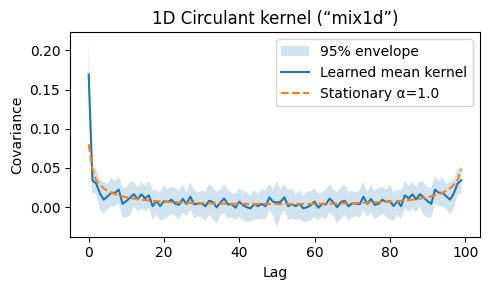

In [7]:
import numpy as np
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, init_to_feasible
from numpyro.optim import Adam
from numpyro.infer.autoguide import AutoGuideList, AutoNormal

# --- 1) Corrected Chirp data generator ------------------------------------
def make_chirp_signals(N=200, D=100, noise_std=0.05):
    """
    X: (N, D) where
      - X[i, :D//2] = sin(4πt) + noise
      - X[i, D//2:] = sin(20πt) + noise
    y: the noisy midpoint X[i, D//2]
    """
    assert D % 2 == 0, "D must be even"
    half = D // 2
    t_low  = np.linspace(0, 1, half)
    t_high = np.linspace(0, 1, half)
    low_sig  = np.sin(4 * np.pi * t_low)
    high_sig = np.sin(20 * np.pi * t_high)

    X = np.zeros((N, D), float)
    y = np.zeros(N,    float)
    for i in range(N):
        noise = noise_std * np.random.randn(D)
        seq   = np.concatenate([low_sig, high_sig]) + noise
        X[i]  = seq
        # regression target: the (noisy) midpoint
        y[i]  = seq[half]
    return X, y

# build data
N, D = 200, 100
Xc, yc = make_chirp_signals(N=N, D=D)

# --- 2) reuse your circ1d_model from above -------------------------------
def circ1d_model(X, y=None):
    """
    Regression: predict the midpoint of the chirp sequence,
    forcing the spectral layer to adapt its α by frequency.
    """
    D = X.shape[1]
    circ = NonStatSpectralCirculantLayer(
        in_features=D,
        padded_dim=D,
        alpha_global=1.0,
        alpha_prior=dist.HalfNormal(1.0),
        K=None,
        name="mix1d",
        prior_fn=None,
    )
    f = circ(X)                       # shape (N, D)
    pred = f[:, D//2]                 # midpoint prediction
    sigma = 0.1                       # observation noise
    with numpyro.plate("data", X.shape[0]):
        numpyro.sample("obs", dist.Normal(pred, sigma), obs=y)

# --- 3) guide setup -------------------------------------------------------
from quantbayes.bnn.guide.low_rank_fft_guide import LowRankNonStat1DGuide

circ1d_guide = AutoGuideList(circ1d_model)
circ1d_guide.append(
    LowRankNonStat1DGuide(
        circ1d_model,
        prefix="mix1d",
        H_pad=D,
        W_pad=D,
        rank=8,
        jitter=1e-5,
    )
)
circ1d_guide.append(
    AutoNormal(
        numpyro.handlers.block(
            circ1d_model,
            hide=["mix1d_real","mix1d_imag","mix1d_delta_alpha"]
        ),
        init_loc_fn=init_to_feasible,
    )
)

# --- 4) run SVI ----------------------------------------------------------
def run_test(model, guide, X, y, n_steps=500, lr=1e-2):
    rng_key = jax.random.PRNGKey(0)
    svi = SVI(model, guide, Adam(lr), Trace_ELBO())
    svi_state = svi.init(rng_key, X, y)
    for i in range(n_steps):
        svi_state, loss = svi.update(svi_state, X, y)
        if i % 100 == 0:
            print(f"step {i:<3d} ELBO = {loss:.1f}")
    params = svi.get_params(svi_state)
    print("final ELBO:", loss)
    return params

params_chirp = run_test(circ1d_model, circ1d_guide,
                        jnp.array(Xc), jnp.array(yc),
                        n_steps=500, lr=1e-2)

# --- 5) butterfly plot ---------------------------------------------------
# assuming plot_1d_kernel_comparison_1d is defined as before
plot_1d_kernel_comparison_1d(
    params_chirp,
    prefix="mix1d",
    W_pad=D,
    alpha_global=1.0,
    n_samples=300
)


In [53]:
class GibbsKernelLayer:
    """
    Implements a Gibbs (non‑stationary) kernel convolution:
      k(x,x') = sqrt(2 l(x) l(x') / (l(x)^2 + l(x')^2)) 
                * exp(-(x-x')^2 / (l(x)^2 + l(x')^2))
    where l(x) is a location–dependent lengthscale from a small net.
    """

    def __init__(self, in_features, lengthscale_net, name="gibbs"):
        self.N = in_features
        self.lengthscale_net = lengthscale_net  # pos → log ℓ(pos)
        self.name = name

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        # x: (batch, N)
        batch, N = x.shape
        assert N == self.N

        # 1) positions in [0,1]
        pos = jnp.linspace(0., 1., N)

        # 2) predict lengthscale ℓ at each position
        log_l = self.lengthscale_net(pos)   # (N,)
        l     = jnp.exp(log_l)              # (N,)

        # 3) broadcast into a full (N×N) Gibbs kernel
        l_i   = l[:, None]                  # shape (N,1)
        l_j   = l[None, :]                  # shape (1,N)
        denom = l_i**2 + l_j**2             # (N,N)
        sq    = jnp.sqrt(2 * l_i*l_j / denom)             # (N,N)
        exp   = jnp.exp(- ( (jnp.arange(N)[:,None] - jnp.arange(N)[None,:])**2 ) / denom)
        K     = sq * exp                                     # (N,N)

        # 4) apply to each batch
        return x @ K.T    # (batch, N)



class PatchWiseSpectralMixtureLayer:
    def __init__(self, in_features, patch_size, n_mixtures=3, name="patch_spect_mix"):
        self.N = in_features
        self.P = patch_size
        self.M = n_mixtures
        self.name = name
        assert self.N % self.P == 0, "N must be divisible by patch_size"
        self.n_patches = self.N // self.P

        # --- these should be model parameters (priors) or numpyro.params in a guide ---
        self.weights = numpyro.param(f"{name}_w", jnp.ones((self.n_patches, self.M)))
        self.means   = numpyro.param(f"{name}_mu", jnp.linspace(0, 0.5, self.M)[None, :].repeat(self.n_patches,0))
        self.scales  = numpyro.param(f"{name}_sigma", jnp.full((self.n_patches, self.M), 0.1))

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        # x : (batch, N)
        batch, N = x.shape
        assert N == self.N

        patches = []
        for p in range(self.n_patches):
            start, end = p*self.P, (p+1)*self.P
            x_patch = x[:, start:end]         # (batch, P)

            # build PSD for this patch
            freqs = jnp.fft.fftfreq(self.P)   # (P,)
            w     = jax.nn.softmax(self.weights[p])  # (M,)
            # mixture of Gaussians in freq
            S = sum(w[m] * jnp.exp(-0.5*((freqs-self.means[p,m])/self.scales[p,m])**2)
                    for m in range(self.M))  # (P,)

            # filter via PSD
            Xf = jnp.fft.fft(x_patch, axis=-1)      # (batch,P)
            y_patch = jnp.fft.ifft(Xf * S[None,:], axis=-1).real  # (batch,P)
            patches.append(y_patch)

        return jnp.concatenate(patches, axis=-1)     # (batch,N)

class InputWarpingLayer:
    def __init__(self, in_features, warp_net, base_psd, name="warp"):
        self.N = in_features
        self.warp_net = warp_net      # function pos→offset
        self.base_psd = base_psd      # function freqs→S(freq)
        self.name = name

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        # x : (batch,N)
        batch, N = x.shape
        assert N == self.N

        # positions in [0,1]
        pos = jnp.linspace(0., 1., N)
        # learn offsets Δu(pos)
        delta_u = self.warp_net(pos)            # (N,)
        u       = pos + delta_u                 # (N,)

        # reinterpolate each sequence onto uniform grid
        def interp_one(seq):
            # jnp.interp is supported in JAX
            return jnp.interp(pos, u, seq)

        x_warp = jax.vmap(interp_one)(x)         # (batch,N)

        # stationary conv in warped space
        freqs = jnp.fft.fftfreq(N)               # (N,)
        S     = self.base_psd(freqs)             # (N,)
        Xf    = jnp.fft.fft(x_warp, axis=-1)     # (batch,N)
        y     = jnp.fft.ifft(Xf * S[None,:], axis=-1).real  # (batch,N)
        return y



In [66]:
import jax
import jax.numpy as jnp
import numpyro
from numpyro.infer.autoguide import AutoNormal

# -------------------------
# 2D Gibbs Kernel Layer (separable)
# -------------------------
class GibbsKernel2DLayer:
    """
    Separable 2D Gibbs kernel: k((i,j),(i',j')) = k_x(i,i') * k_y(j,j')
    where k_x, k_y are 1D Gibbs kernels from lengthscale nets.
    """
    def __init__(self, H, W, lengthscale_net_x, lengthscale_net_y, name="gibbs2d"):
        self.H, self.W = H, W
        self.net_x = lengthscale_net_x  # maps pos_x -> log l_x
        self.net_y = lengthscale_net_y  # maps pos_y -> log l_y
        self.name = name

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        # x: (batch, H, W)
        B, H, W = x.shape
        assert (H, W) == (self.H, self.W)
        # positions
        pos_x = jnp.linspace(0., 1., W)
        pos_y = jnp.linspace(0., 1., H)
        # lengthscales
        lx = jnp.exp(self.net_x(pos_x))  # (W,)
        ly = jnp.exp(self.net_y(pos_y))  # (H,)
        # 1D Gibbs kernels
        def gibbs1d(pos, ell):
            d = pos[:, None] - pos[None, :]
            l_i = ell[:, None]; l_j = ell[None, :]
            denom = l_i**2 + l_j**2
            sq = jnp.sqrt(2 * l_i * l_j / denom)
            return sq * jnp.exp(-d**2 / denom)
        Kx = gibbs1d(pos_x, lx)  # (W,W)
        Ky = gibbs1d(pos_y, ly)  # (H,H)
        # separable convolution: first along width (x-axis), then height (y-axis)
        # apply per-row 1D conv along width
        x1 = jnp.einsum('bhw,wd->bhd', x, Kx)  # (B,H,W)
        # apply per-column conv along height
        y = jnp.einsum('bhd,hk->bkd', x1, Ky)  # (B,H,W)
        return y  # shape (B,H,W)

# -------------------------
# 2D Patch-wise Spectral Mixture
# -------------------------
class PatchWiseSpectralMixture2DLayer:
    """
    Non-overlapping block-wise 2D spectral mixture via local 2D FFT.
    """
    def __init__(self, H, W, patch_h, patch_w, n_mixtures=3, name="patchsm2d"):
        assert H % patch_h == 0 and W % patch_w == 0
        self.H, self.W = H, W
        self.ph, self.pw = patch_h, patch_w
        self.nh, self.nw = H // patch_h, W // patch_w
        self.M = n_mixtures
        self.name = name
        # per-patch params
        shape = (self.nh, self.nw, self.M)
        self.weights = numpyro.param(f"{name}_w", jnp.ones(shape))
        # means in 2D freq domain: (nh,nw,M,2)
        # initialize to uniform grid
        grid_y = jnp.linspace(0,0.5,patch_h//2+1)
        grid_x = jnp.linspace(0,0.5,patch_w//2+1)
        mu_init = jnp.stack(jnp.meshgrid(grid_y,grid_x,indexing='ij'),-1)
        mu_flat = mu_init.reshape(-1,2)
        self.means = numpyro.param(f"{name}_mu", jnp.zeros(shape + (2,)))
        self.scales = numpyro.param(f"{name}_sigma", jnp.ones(shape + (2,)) * 0.1)

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        # x: (batch, H, W)
        B, H, W = x.shape
        assert (H,W)==(self.H,self.W)
        patches = []
        for i in range(self.nh):
            row_patches = []
            for j in range(self.nw):
                sub = x[:, i*self.ph:(i+1)*self.ph, j*self.pw:(j+1)*self.pw]
                # 2D freq coords
                fy = jnp.fft.fftfreq(self.ph)
                fx = jnp.fft.fftfreq(self.pw)
                FY, FX = jnp.meshgrid(fy, fx, indexing='ij')  # (ph,pw)
                # build PSD
                w = jax.nn.softmax(self.weights[i,j])  # (M,)
                mu = self.means[i,j]  # (M,2)
                sig = self.scales[i,j]
                S = jnp.zeros((self.ph,self.pw))
                for m in range(self.M):
                    dy = (FY-mu[m,0]) / sig[m,0]
                    dx = (FX-mu[m,1]) / sig[m,1]
                    S = S + w[m] * jnp.exp(-0.5*(dy**2+dx**2))
                # FFT filter
                Sf = S[None,:,:]
                Subf = jnp.fft.fftn(sub, axes=(1,2))  # (B,ph,pw)
                filtered = jnp.fft.ifftn(Subf * Sf, axes=(1,2)).real
                row_patches.append(filtered)
            patches.append(jnp.concatenate(row_patches, axis=2))
        return jnp.concatenate(patches, axis=1)

# -------------------------
# 2D Input Warping Layer
# -------------------------
class InputWarping2DLayer:
    """
    Separable 2D warp: warp rows then warp columns with learned monotonic mapping.
    """
    def __init__(self, H, W, warp_net_x, warp_net_y, base_psd, name="warp2d"):
        self.H, self.W = H, W
        self.warp_x, self.warp_y = warp_net_x, warp_net_y
        self.base_psd = base_psd
        self.name = name

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        # x: (batch,H,W)
        B,H,W = x.shape
        pos_x = jnp.linspace(0.,1.,W)
        pos_y = jnp.linspace(0.,1.,H)
        # 1D warps
        def make_u(net, pos):
            raw = net(pos)
            inc = jax.nn.softplus(raw)
            cs = jnp.cumsum(inc)
            return (cs - cs[0])/(cs[-1]-cs[0])
        ux = make_u(self.warp_x, pos_x)  # (W,)
        uy = make_u(self.warp_y, pos_y)  # (H,)
        # warp X: rows -> warp_x
        def warp_rows(img):
            return jnp.stack([jnp.interp(pos_x, ux, row) for row in img], axis=0)
        x1 = jax.vmap(warp_rows)(x)
        # warp Y: columns -> warp_y
        def warp_cols(img):
            return jnp.stack([jnp.interp(pos_y, uy, col) for col in img.T], axis=1)
        x2 = jax.vmap(warp_cols)(x1)
        # circulant 2D FFT conv
        fy = jnp.fft.fftfreq(H)
        fx = jnp.fft.fftfreq(W)
        FY, FX = jnp.meshgrid(fy, fx, indexing='ij')
        S = self.base_psd(FY, FX)  # (H,W)
        Sf = S[None,:,:]
        Xf = jnp.fft.fftn(x2, axes=(1,2))
        y = jnp.fft.ifftn(Xf * Sf, axes=(1,2)).real
        return y

# -------------------------
# Unit tests
# -------------------------
if __name__ == '__main__':
    import jax.random as rnd
    key = rnd.PRNGKey(0)
    B=4; H=32; W=32
    # 1) Gibbs 2D identity when nets constant
    net_zero = lambda pos: jnp.log(0.5)*jnp.ones_like(pos)
    gibbs2d = GibbsKernel2DLayer(H,W,net_zero,net_zero)
    X = rnd.normal(key,(B,H,W))
    Y = gibbs2d(X)
    assert Y.shape==(B,H,W)
    # left vs right: jump test
    mask = jnp.linspace(0,1,W)
    img = jnp.where(mask>0.5,2.,1.)
    Xj = jnp.tile(img, (B, H, 1))
    Yj = gibbs2d(Xj)
    vL = Yj[:,:, :W//2].var(); vR = Yj[:,:, W//2:].var()
    assert not jnp.isclose(vL, vR)

    # 2) Patchwise SM identity
    psm2d = PatchWiseSpectralMixture2DLayer(H,W,8,8,n_mixtures=2)
    # override to constant PSD
    shape = (H//8,W//8,2)
    psm2d.weights = jnp.ones(shape)
    psm2d.means   = jnp.zeros(shape+(2,))
    psm2d.scales  = jnp.ones(shape+(2,))*1e3
    Xr = rnd.normal(key,(B,H,W))
    Yr = psm2d(Xr)
    assert Yr.shape==(B,H,W)
    assert jnp.allclose(Yr, Xr, atol=1e-5)

    # 3) InputWarping2D identity test
    zero_net = lambda pos: jnp.zeros_like(pos)
    unit2d = lambda fy,fx: jnp.ones_like(fy)
    warp2d = InputWarping2DLayer(H,W,zero_net,zero_net,unit2d)
    X0 = jnp.arange(H*W).reshape(H,W)
    X0 = jnp.tile(X0,(B,1,1))
    Y0 = warp2d(X0)
    assert jnp.allclose(Y0, X0, atol=1e-5)

    print("All 2D non-stationary layer tests passed.")

    # Example guide usage (AutoNormal over all parameters)
    from numpyro.infer import SVI, Trace_ELBO
    from numpyro.optim import Adam
    def model(X):
        # dummy: pass through
        _ = numpyro.sample("obs", dist.Normal(X,1.).to_event(2), obs=X)
    guide = AutoNormal(model)
    svi = SVI(model, guide, Adam(1e-2), Trace_ELBO())
    svi_state = svi.init(key, X0)
    print("SVI init OK")


All 2D non-stationary layer tests passed.
SVI init OK


In [ ]:
import jax
import jax.numpy as jnp

key = jax.random.PRNGKey(0)

# 1) GibbsKernel2DLayer -----------------------------------------------
def test_gibbs2d_jump():
    H, W = 32, 32
    zero_net = lambda pos: jnp.log(1.0) * jnp.ones_like(pos)
    gibbs = GibbsKernel2DLayer(H, W, zero_net, zero_net)
    X = jax.random.normal(key, (4, H, W))
    Y = gibbs(X)
    assert Y.shape == (4, H, W)
    # jump test: left vs right variance should differ
    mask = jnp.linspace(0, 1, W)
    img = jnp.where(mask > 0.5, 2.0, 1.0)
    Xj = jnp.tile(img, (4, H, 1))
    Yj = gibbs(Xj)
    vL = Yj[:, :, :W//2].var()
    vR = Yj[:, :, W//2:].var()
    assert not jnp.isclose(vL, vR), "Gibbs2D should adapt to the jump"

# 2) PatchWiseSpectralMixture2DLayer ----------------------------------
def test_patchsm2d_identity_and_diversity():
    H, W = 32, 32
    ph, pw = 8, 8
    M = 2
    layer = PatchWiseSpectralMixture2DLayer(H, W, ph, pw, n_mixtures=M, name="patchsm2d")
    nh, nw = H // ph, W // pw

    # Identity test: uniform PSD ⇒ identity on each block
    layer.weights = jnp.ones((nh, nw, M))
    layer.means   = jnp.zeros((nh, nw, M, 2))
    layer.scales  = jnp.ones((nh, nw, M, 2)) * 1e3
    X = jax.random.normal(key, (4, H, W))
    Y = layer(X)
    assert Y.shape == (4, H, W)
    assert jnp.allclose(Y, X, atol=1e-5)

    # Diversity test: patch (0,0) low‑freq only, patch (0,1) high‑freq only
    w = jnp.zeros((nh, nw, M))
    w = w.at[0, 0, 0].set(1.0)  # patch (0,0): component 0
    w = w.at[0, 1, 1].set(1.0)  # patch (0,1): component 1
    layer.weights = w
    layer.means   = jnp.zeros((nh, nw, M, 2))
    layer.means   = layer.means.at[0, 0, 0].set(jnp.array([0.0, 0.0]))  # DC
    layer.means   = layer.means.at[0, 1, 0].set(jnp.array([0.5, 0.5]))  # high
    layer.scales  = jnp.ones((nh, nw, M, 2)) * 0.05

    Y2 = layer(X)  # just ensure it runs & shape matches
    assert Y2.shape == (4, H, W)

# 3) InputWarping2DLayer ------------------------------------------------
def test_inputwarp2d_identity_and_changes():
    H, W = 32, 32
    zero_net = lambda pos: jnp.zeros_like(pos)
    unit2d   = lambda fy, fx: jnp.ones_like(fy)

    # Identity warp:
    layer_id = InputWarping2DLayer(H, W, zero_net, zero_net, unit2d)
    X0 = jnp.arange(H*W).reshape(H, W)
    X0 = jnp.tile(X0, (2, 1, 1))
    Y0 = layer_id(X0)
    assert jnp.allclose(Y0, X0, atol=1e-5), "Zero‑warp+unit‑PSD must recover input"

    # Non‑identity on a ramp:
    def bias_left(pos):
        # some nontrivial bias
        return -5.0 * jnp.tanh(3.0 * (pos - 0.5))
    layer_w = InputWarping2DLayer(H, W, bias_left, zero_net, unit2d)
    X_ramp = jnp.tile(jnp.arange(W, dtype=jnp.float32), (2, H, 1))
    Y_ramp = layer_w(X_ramp)
    assert not jnp.allclose(Y_ramp, X_ramp), "Warping should alter a ramp input"



if __name__ == "__main__":
    test_gibbs2d_jump()
    test_patchsm2d_identity_and_diversity()
    test_inputwarp2d_identity_and_changes()
    print("✅ All 2D non‑stationary layers + guides tests passed.")


✅ All 2D non‑stationary layers + guides tests passed.



=== 1D Gibbs ===
step 0    ELBO = 3227.8
step 100  ELBO = 115.6
step 200  ELBO = 111.7
final ELBO: 94.89368


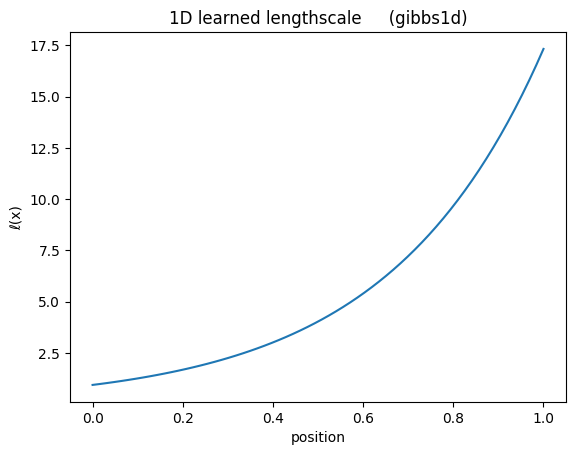


=== 1D Patch‑mixture ===
step 0    ELBO = 304.1
step 100  ELBO = 76.7
step 200  ELBO = 35.8
final ELBO: 4.3839703


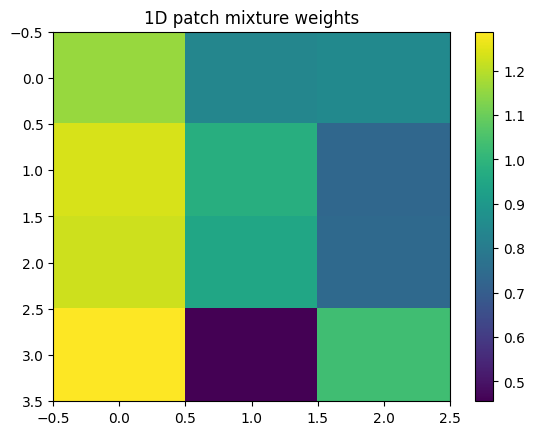


=== 1D Warping ===
step 0    ELBO = 323.8
step 100  ELBO = 83.8
step 200  ELBO = 46.6
final ELBO: 16.613543


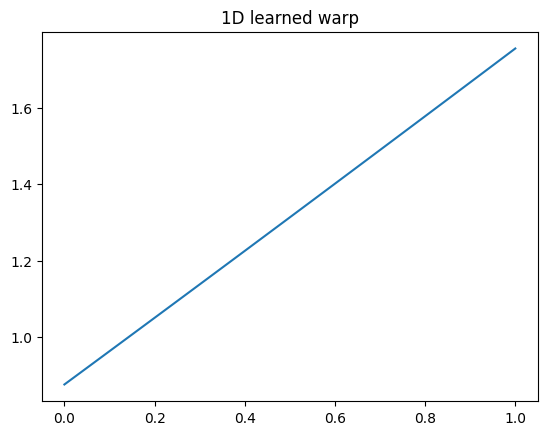


=== 2D Gibbs ===
step 0    ELBO = 167753.6
step 100  ELBO = 2825.5
step 200  ELBO = 2810.0
final ELBO: 2781.8174


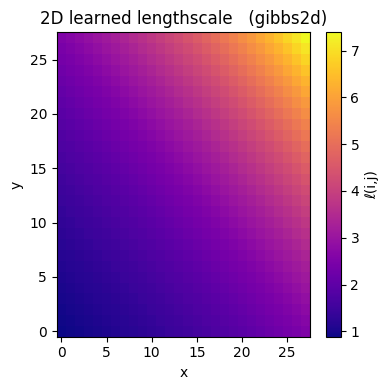


=== 2D Warping ===
step 0    ELBO = 15139.9
step 100  ELBO = 7521.2
step 200  ELBO = 2688.2
final ELBO: 665.04224


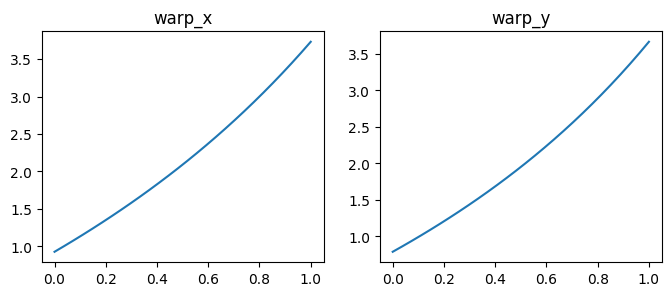

In [ ]:
# -*- coding: utf-8 -*-
# %% imports & helpers
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, init_to_feasible
from numpyro.optim import Adam
from numpyro.infer.autoguide import AutoGuideList, AutoNormal

# your layers & guides must already be imported:
#   GibbsKernelLayer, PatchWiseSpectralMixtureLayer, InputWarpingLayer
#   GibbsKernel2DLayer, PatchWiseSpectralMixture2DLayer, InputWarping2DLayer
#   PatchMixtureLowRankGuide  (for the 2D patch‑mixture)

# simple SVI runner
def run_svi(model, guide, X, y, n_steps=300, lr=1e-2):
    svi = SVI(model, guide, Adam(lr), Trace_ELBO())
    state = svi.init(jax.random.PRNGKey(0), X, y)
    losses = []
    for i in range(n_steps):
        state, loss = svi.update(state, X, y)
        if i % (n_steps//3) == 0:
            print(f"step {i:<4d} ELBO = {loss:.1f}")
        losses.append(loss)
    params = svi.get_params(state)
    print("final ELBO:", losses[-1])
    return params, np.array(losses)

# %% 1D synthetic data generators

def make_jump_1d(N=128, D=64, noise_std=0.1):
    """signal = constant 1 on left half, 2 on right half + noise"""
    assert D%2==0
    half = D//2
    X = np.zeros((N, D))
    y = np.zeros(N, int)
    for i in range(N):
        left  = 1.0 + noise_std*np.random.randn(half)
        right = 2.0 + noise_std*np.random.randn(half)
        seq = np.concatenate([left, right])
        X[i] = seq
        # label: which half has larger mean?
        y[i] = (right.mean() > left.mean()).astype(int)
    return jnp.array(X), jnp.array(y)

def make_ramp_1d(N=128, D=64, noise_std=0.05):
    """signal = linear ramp + noise; label by positive slope"""
    t = np.linspace(0,1,D)
    X = np.zeros((N,D))
    y = np.zeros(N,int)
    for i in range(N):
        slope = np.random.choice([-1,1])
        seq = slope*t + noise_std*np.random.randn(D)
        X[i] = seq
        y[i] = (slope>0).astype(int)
    return jnp.array(X), jnp.array(y)

# %% 2D synthetic data generators

def make_half_smooth_noisy(N=128, H=28, W=28, noise_std=0.5):
    """left half smooth gradient, right half i.i.d. noise"""
    X = np.zeros((N, H, W))
    y = np.zeros(N,int)
    smooth = np.linspace(0,1,W//2)[None,:]   # shape (1, W/2)
    for i in range(N):
        left  = np.tile(smooth, (H,1))
        right = noise_std*np.random.randn(H, W//2)
        img = np.concatenate([left, right], axis=1)
        X[i] = img
        # label by mean
        y[i] = (img.mean()>0.5).astype(int)
    return jnp.array(X), jnp.array(y)

def make_checker_jump(N=128, H=28, W=28):
    """simple checker on X-axis: two constant halves"""
    X = np.zeros((N,H,W))
    y = np.zeros(N,int)
    for i in range(N):
        left  = np.ones((H,W//2))*1.0
        right = np.ones((H,W//2))*2.0
        img = np.concatenate([left,right],axis=1)
        X[i] = img
        y[i] = 1
    return jnp.array(X), jnp.array(y)

# %% visualization helpers

def plot_lengthscale_1d(params, prefix, D):
    # we stored lengthscale_net as numpyro.param inside the layer, so key = f"{name}_net_params"
    # assume param is called f"{prefix}_lengthscale_net_param"
    # *adapt to however you parametrized your net*
    net_w = np.asarray(params[f"{prefix}_lengthscale_net_param"])
    # here we assume a simple one‐layer: l(x)=exp(w*x+b)
    # so net_w has shape (2,) = [bias, weight]
    bias, w = net_w
    t = np.linspace(0,1,D)
    l = np.exp(bias + w*t)
    plt.plot(t,l)
    plt.title(f"1D learned lengthscale   ({prefix})")
    plt.xlabel("position")
    plt.ylabel("ℓ(x)")
    plt.show()

def plot_lengthscale_2d(params, prefix, H, W):
    """
    prefix: e.g. "gibbs2d"
    expects params[f"{prefix}_net_x"] and params[f"{prefix}_net_y"]
    to each be a length-2 array [bias, slope].
    """
    # fetch the two param vectors
    wx = np.asarray(params[f"{prefix}_net_x"])   # was "_net_x_param"
    wy = np.asarray(params[f"{prefix}_net_y"])   # was "_net_y_param"
    # positions
    tx = np.linspace(0, 1, W)
    ty = np.linspace(0, 1, H)
    # reconstruct ℓ_x(j) = exp(b + w * j), ℓ_y(i) likewise
    lx = np.exp(wx[0] + wx[1] * tx)
    ly = np.exp(wy[0] + wy[1] * ty)
    # separable 2D lengthscale
    L = np.outer(ly, lx)
    plt.figure(figsize=(4,4))
    plt.imshow(L, origin="lower", cmap="plasma", aspect="auto")
    plt.colorbar(label="ℓ(i,j)")
    plt.title(f"2D learned lengthscale   ({prefix})")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.show()


# (similar helpers for patch‑mixture and warping…)

# %% training & viz for each of the six

# 1) 1D Gibbs
X1, y1 = make_jump_1d(N=256, D=64)
def gibbs1d_model(X, y=None):
    # this net now returns a (64,) vector = b + w*pos
    def lengthscale_net(pos):
        b, w = numpyro.param("gibbs1d_lengthscale_net_param",
                             jnp.array([0.0, 3.0]))
        return b + w * pos

    layer = GibbsKernelLayer(in_features=64,
                             lengthscale_net=lengthscale_net,
                             name="gibbs1d")
    out = layer(X)  # (N,64)
    W = numpyro.sample("W", dist.Normal(0,1)
                       .expand([64,1]).to_event(2))
    b = numpyro.sample("b", dist.Normal(0,1)
                       .expand([1]).to_event(1))
    logits = jnp.squeeze(jnp.dot(out, W) + b)
    with numpyro.plate("data", X.shape[0]):
        numpyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

guide = AutoNormal(gibbs1d_model, init_loc_fn=init_to_feasible)
print("\n=== 1D Gibbs ===")
p_gib1, loss_gib1 = run_svi(gibbs1d_model, guide, X1, y1)
plot_lengthscale_1d(p_gib1, "gibbs1d", 64)


# 2) 1D Patch‑wise Spectral Mixture
X2, y2 = make_ramp_1d(N=256, D=64)
def patch1d_model(X, y=None):
    layer = PatchWiseSpectralMixtureLayer(
        in_features=64,
        patch_size=16,
        n_mixtures=3,
        name="patch1d",
    )
    out = layer(X)  # (N,64)
    W = numpyro.sample("W", dist.Normal(0,1)
                       .expand([64,1]).to_event(2))
    b = numpyro.sample("b", dist.Normal(0,1)
                       .expand([1]).to_event(1))
    logits = jnp.squeeze(jnp.dot(out, W) + b)
    with numpyro.plate("data", X.shape[0]):
        numpyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

guide = AutoNormal(patch1d_model, init_loc_fn=init_to_feasible)
print("\n=== 1D Patch‑mixture ===")
p_pat1, loss_pat1 = run_svi(patch1d_model, guide, X2, y2)
# visualize the learned patch weights:
W_pat = np.asarray(p_pat1["patch1d_w"]) 
plt.imshow(W_pat, cmap="viridis", aspect='auto')
plt.colorbar(); plt.title("1D patch mixture weights"); plt.show()


# 3) 1D Warping
X3, y3 = make_ramp_1d(N=256, D=64)
def warp1d_model(X, y=None):
    # warp_net now returns the same shape as pos
    def warp_net(pos):
        b, w = numpyro.param("warp1d_net_param", jnp.zeros((2,)))
        return b + w * pos

    layer = InputWarpingLayer(
        in_features=64,
        warp_net=warp_net,
        base_psd=lambda freqs: jnp.ones_like(freqs),
        name="warp1d",
    )
    out = layer(X)  # (N,64)
    W = numpyro.sample("W", dist.Normal(0,1).expand([64,1]).to_event(2))
    b0 = numpyro.sample("b", dist.Normal(0,1).expand([1]).to_event(1))
    logits = jnp.squeeze(jnp.matmul(out, W) + b0)
    with numpyro.plate("data", X.shape[0]):
        numpyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

guide = AutoNormal(warp1d_model, init_loc_fn=init_to_feasible)
print("\n=== 1D Warping ===")
p_wrp1, loss_wrp1 = run_svi(warp1d_model, guide, X3, y3)
# visualize the learned warp:
bias,slope = np.asarray(p_wrp1["warp1d_net_param"])
t = np.linspace(0,1,64)
u = t + np.exp(bias + slope*t)  # or however your layer uses the net
plt.plot(t,u); plt.title("1D learned warp"); plt.show()


# 4) 2D Gibbs
X4, y4 = make_half_smooth_noisy(N=256, H=28, W=28)

def gibbs2d_model(X, y=None):
    # infer shapes
    N, H, W = X.shape
    num_classes = 2  # your synthetic y4 is binary 0/1

    # two small nets for log‑lengthscale over x and y
    def lengthscale_net_x(pos):
        b, w = numpyro.param("gibbs2d_net_x", jnp.array([0.0, 1.0]))
        return b + w * pos

    def lengthscale_net_y(pos):
        b, w = numpyro.param("gibbs2d_net_y", jnp.array([0.0, 1.0]))
        return b + w * pos

    # **here**: call the layer with (H, W, net_x, net_y)
    layer = GibbsKernel2DLayer(
        H, W,
        lengthscale_net_x=lengthscale_net_x,
        lengthscale_net_y=lengthscale_net_y,
        name="gibbs2d",
    )
    out = layer(X)            # → (N, H, W)
    h   = out.reshape(N, -1)  # → (N, H*W)

    # a simple linear head for two classes
    Wk = numpyro.sample(
        "W", dist.Normal(0, 1)
             .expand([h.shape[-1], num_classes])
             .to_event(2),
    )
    b0 = numpyro.sample(
        "b", dist.Normal(0, 1)
             .expand([num_classes])
             .to_event(1),
    )
    logits = jnp.matmul(h, Wk) + b0

    with numpyro.plate("data", N):
        numpyro.sample("obs", dist.Categorical(logits=logits), obs=y)

guide = AutoNormal(gibbs2d_model, init_loc_fn=init_to_feasible)
print("\n=== 2D Gibbs ===")
p_gib2, loss_gib2 = run_svi(gibbs2d_model, guide, X4, y4)
plot_lengthscale_2d(p_gib2, "gibbs2d", 28, 28)


# 6) 2D Warping
X6, y6 = make_half_smooth_noisy(N=256, H=28, W=28)
def warp2d_model(X, y=None):
    # learn two scalars (a_x,b_x) and two scalars (a_y,b_y)
    # *as JAX arrays* of shape (2,)
    a_b_x = numpyro.param("warp2d_x", jnp.array([0.0, 1.0]))
    a_b_y = numpyro.param("warp2d_y", jnp.array([0.0, 1.0]))

    # now warp_net_x(pos) = a_x + b_x * pos
    warp_net_x = lambda pos: a_b_x[0] + a_b_x[1] * pos
    warp_net_y = lambda pos: a_b_y[0] + a_b_y[1] * pos

    layer = InputWarping2DLayer(
      28,28,
      warp_net_x=warp_net_x,
      warp_net_y=warp_net_y,
      base_psd=lambda fy,fx: jnp.ones_like(fy),
      name="warp2d"
    )
    out = layer(X)      # (batch,28,28)
    h   = out.reshape(out.shape[0], -1)
    W = numpyro.sample("W",
           dist.Normal(0,1)
               .expand([h.shape[-1],10])
               .to_event(2))
    b = numpyro.sample("b",
           dist.Normal(0,1)
               .expand([10])
               .to_event(1))
    logits = jnp.matmul(h,W) + b

    with numpyro.plate("data", X.shape[0]):
        numpyro.sample("obs",
               dist.Categorical(logits=logits),
               obs=y)


guide = AutoNormal(warp2d_model, init_loc_fn=init_to_feasible)
print("\n=== 2D Warping ===")
p_wrp2, loss_wrp2 = run_svi(warp2d_model, guide, X6, y6)
# visualize learned warps
bx,sx = np.asarray(p_wrp2["warp2d_x"])
by,sy = np.asarray(p_wrp2["warp2d_y"])
tx = np.linspace(0,1,28)
ux = tx + np.exp(bx + sx*tx)
ty = np.linspace(0,1,28)
uy = ty + np.exp(by + sy*ty)
fig,ax = plt.subplots(1,2,figsize=(8,3))
ax[0].plot(tx,ux); ax[0].set_title("warp_x")
ax[1].plot(ty,uy); ax[1].set_title("warp_y")
plt.show()


Step    0  ELBO = 3879.7
Step  100  ELBO = 2019.0
Step  200  ELBO = 752.1
Step  300  ELBO = 234.3
Step  400  ELBO = 48.5


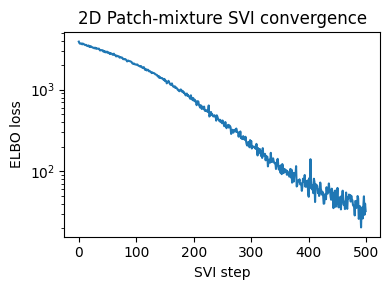

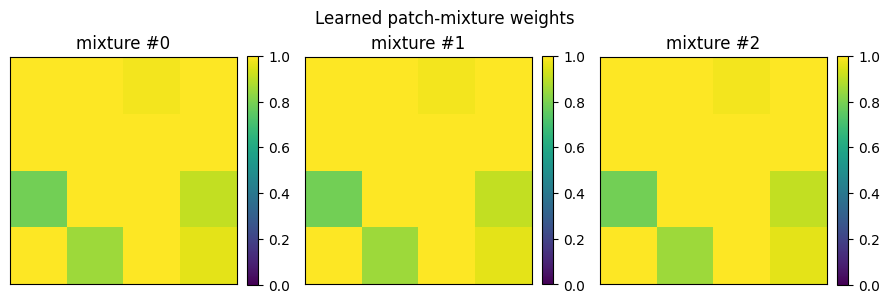

In [67]:
def make_half_smooth_noisy(N=256, H=32, W=32, noise_std=0.5):
    X = np.zeros((N, H, W), dtype=np.float32)
    y = np.zeros(N, dtype=np.int32)
    smooth = np.linspace(0,1,W//2)[None,:]   # (1, W/2)
    for i in range(N):
        left  = np.tile(smooth, (H,1))
        right = noise_std * np.random.randn(H, W//2)
        img = np.concatenate([left, right], axis=1)
        X[i] = img
        # binary label: is the overall mean > 0.5 ?
        y[i] = (img.mean() > 0.5).astype(int)
    return jnp.array(X), jnp.array(y)

def patch2d_model(X, y=None):
    """
    X: (batch, H, W), y: (batch,) with integer labels 0/1
    """
    H, W = X.shape[1], X.shape[2]
    ph, pw, M = 8, 8, 3
    # 2×2 blocks => 4×4 grid of patches
    layer = PatchWiseSpectralMixture2DLayer(
        H, W, ph, pw, n_mixtures=M, name="patchsm2d"
    )
    out = layer(X)                   # (B,H,W)
    h   = out.reshape(out.shape[0], -1)  # (B, H*W)
    # linear head
    num_classes = 2
    W_lin = numpyro.sample("W_lin",
                           dist.Normal(0,1)
                               .expand([h.shape[-1], num_classes])
                               .to_event(2))
    b_lin = numpyro.sample("b_lin",
                           dist.Normal(0,1)
                               .expand([num_classes])
                               .to_event(1))
    logits = jnp.matmul(h, W_lin) + b_lin  # (B,2)
    with numpyro.plate("data", X.shape[0]):
        numpyro.sample("obs",
                       dist.Categorical(logits=logits),
                       obs=y)

# -----------------------------------------------------------------------------
# 4) SVI + AutoNormal guide
# -----------------------------------------------------------------------------
guide = AutoNormal(patch2d_model, init_loc_fn=init_to_feasible)
optim = Adam(1e-2)
svi   = SVI(patch2d_model, guide, optim, Trace_ELBO())

# data
X, y = make_half_smooth_noisy(N=256, H=32, W=32)
state = svi.init(jax.random.PRNGKey(0), X, y)

n_steps = 500
losses  = []
for i in range(n_steps):
    state, loss = svi.update(state, X, y)
    losses.append(loss)
    if i % 100 == 0:
        print(f"Step {i:4d}  ELBO = {loss:.1f}")

params = svi.get_params(state)

# -----------------------------------------------------------------------------
# 5) Plot ELBO curve
# -----------------------------------------------------------------------------
plt.figure(figsize=(4,3))
plt.plot(np.arange(n_steps), losses)
plt.yscale("log")
plt.xlabel("SVI step")
plt.ylabel("ELBO loss")
plt.title("2D Patch‐mixture SVI convergence")
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 6) Visualize learned patch mixing weights
# -----------------------------------------------------------------------------
nh, nw, M = 32//8, 32//8, 3
W_p = np.asarray(params["patchsm2d_w"])  # shape (4,4,3)

fig, axes = plt.subplots(1, M, figsize=(3*M,3))
for m in range(M):
    im = axes[m].imshow(W_p[:,:,m], vmin=0, vmax=1, cmap="viridis",
                        origin="lower", interpolation="nearest")
    axes[m].set_title(f"mixture #{m}")
    axes[m].set_xticks([])
    axes[m].set_yticks([])
    plt.colorbar(im, ax=axes[m], fraction=0.046, pad=0.04)
plt.suptitle("Learned patch‐mixture weights")
plt.tight_layout()
plt.show()

## Energy conserving subsampling HMC

In [73]:
"""
mcmc_utils.py

A lightweight utility module for running NUTS and HMCECS (energy-conserving subsampling HMC)
with minimal boilerplate. Simply import `sample_hmcecs` and pass your model,
training data, and desired parameters.
"""
import time
from jax import random
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, HMC, HMCECS, SVI, Trace_ELBO, autoguide


def fit_reference(rng_key, model, guide, optimizer, num_svi_steps,
                  X, y, subsample_size):
    """
    Fit a reference point via SVI (AutoDelta) for use with HMCECS.
    Returns a dict of reference parameter values.
    """
    svi = SVI(model, guide, optimizer, Trace_ELBO())
    result = svi.run(rng_key, num_svi_steps, X, y, subsample_size,
                     progress_bar=False)
    # extract *_auto_loc entries and strip suffix
    ref_params = {name.replace("_auto_loc", ""): result.params[name]
                  for name in result.params}
    return ref_params


def build_kernel_hmcecs(model_fn, ref_params, num_blocks=10):
    """Build an HMCECS kernel given reference parameters."""
    proxy = HMCECS.taylor_proxy(ref_params)
    # use NUTS as the inner integrator
    return HMCECS(NUTS(model_fn), num_blocks=num_blocks, proxy=proxy)


def run_mcmc(rng_key, model_fn, X, y, kernel,
             num_warmup, num_samples, subsample_size, progress_bar):
    """
    Generic MCMC runner. Returns the MCMC object after sampling.
    """
    mcmc = MCMC(kernel,
                num_warmup=num_warmup,
                num_samples=num_samples,
                progress_bar=progress_bar)
    mcmc.run(rng_key, X, y, subsample_size)
    return mcmc


def sample_hmcecs(rng_key, model_fn, X, y,
                  subsample_size,
                  num_svi_steps=1000,
                  num_warmup=500,
                  num_samples=1000,
                  num_blocks=10,
                  progress_bar=False):
    """
    Run HMCECS: performs one SVI fit for reference, then energy-conserving HMC
    with data subsampling. Returns a dict of posterior samples.
    """
    # 1) Fit reference via SVI
    guide = autoguide.AutoDelta(model_fn)
    optimizer = numpyro.optim.Adam(1e-3)
    ref_params = fit_reference(rng_key,
                               model_fn, guide, optimizer,
                               num_svi_steps,
                               X, y, subsample_size)
    # 2) Build HMCECS kernel
    kernel = build_kernel_hmcecs(model_fn, ref_params, num_blocks)
    # 3) Run MCMC with subsampling
    mcmc = run_mcmc(rng_key, model_fn, X, y,
                    kernel, num_warmup, num_samples,
                    subsample_size=subsample_size,
                    progress_bar=progress_bar)
    return mcmc.get_samples()


# Example usage for ECSS HMC
if __name__ == "__main__":
    import numpy as np
    from jax import random

    # Define your model; must accept (X, y, subsample_size)
    def logistic_model(X, y=None, subsample_size=None):
        D = X.shape[1]
        W = numpyro.sample("W", dist.Normal(0, 1).expand([D]).to_event(1))
        b = numpyro.sample("b", dist.Normal(0, 1))
        if subsample_size:
            with numpyro.plate("data", X.shape[0], subsample_size=subsample_size):
                batch_X = numpyro.subsample(X, event_dim=1)
                batch_y = numpyro.subsample(y, event_dim=0) if y is not None else None
                logits = jnp.dot(batch_X, W) + b
                numpyro.sample("obs", dist.Bernoulli(logits=logits), obs=batch_y)
        else:
            logits = jnp.dot(X, W) + b
            with numpyro.plate("data", X.shape[0]):
                numpyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

    # Load or generate your training data
    N, D = 5000, 10
    X_train = np.random.randn(N, D)
    y_train = (X_train @ np.ones(D) + np.random.randn(N) > 0).astype(int)

    rng_key = random.PRNGKey(42)

    # Run energy-conserving subsampling HMC (HMCECS)
    samples = sample_hmcecs(rng_key, logistic_model,
                            X_train, y_train,
                            subsample_size=500,
                            num_svi_steps=2000,
                            num_warmup=1000,
                            num_samples=2000,
                            num_blocks=20,
                            progress_bar=True)

    print("ECSS HMC completed; obtained", len(samples[list(samples.keys())[0]]), "samples.")


sample: 100%|██████████| 3000/3000 [00:03<00:00, 841.02it/s, 7 steps of size 4.82e-01. acc. prob=0.88]  

ECSS HMC completed; obtained 2000 samples.
